# Section 4: Attention and Convolution (Coding)

This notebook explores the properties of self-attention and connections between self-attention and convolution.

**Similarity Metric Definition:**
A function $s: \mathbb{R}^{d \times d} \to \mathbb{R}$ is a similarity metric if:
1. $s$ is bounded above by some value $b$
2. $s(\mathbf{x}, \mathbf{x}) = b$ (self-similarity is maximum)
3. $\mathbf{x} \neq \mathbf{y} \implies s(\mathbf{x}, \mathbf{y}) < b$ (distinct objects have less than max similarity)
4. $s(\mathbf{x}, \mathbf{y}) = s(\mathbf{y}, \mathbf{x})$ (symmetry)

## Setup: Import Libraries and Create Input Data

In [1]:
# Cell 1: Import necessary libraries
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.3.1
Device: cpu


In [2]:
# Cell 2: Create the input tensor and kernels (from the Colab starter notebook)
# This creates a simple image with colored squares that we'll use throughout the problem

# Create an input image with 3 color channels (RGB), 10x10 pixels
input_tensor = torch.zeros((3, 10, 10))

# Red square in top-left (2x2)
input_tensor[0, 0:2, 0:2] = 1.0  # Red channel

# Green square in top-right (2x2)
input_tensor[1, 0:2, 8:10] = 1.0  # Green channel

# Blue square in bottom-left (2x2)
input_tensor[2, 8:10, 0:2] = 1.0  # Blue channel

# Yellow square in bottom-right (2x2) - Yellow = Red + Green
input_tensor[0, 8:10, 8:10] = 1.0  # Red channel
input_tensor[1, 8:10, 8:10] = 1.0  # Green channel

# Create convolutional kernels (1x1 filters) matching each color
kernels = torch.zeros((4, 3, 1, 1))  # 4 filters, 3 input channels, 1x1 kernel

# Red filter
kernels[0, 0, 0, 0] = 1.0

# Green filter
kernels[1, 1, 0, 0] = 1.0

# Blue filter
kernels[2, 2, 0, 0] = 1.0

# Yellow filter (Red + Green)
kernels[3, 0, 0, 0] = 1.0
kernels[3, 1, 0, 0] = 1.0

print(f"Input tensor shape: {input_tensor.shape} (C, H, W)")
print(f"Kernels shape: {kernels.shape} (d_out, d_in, h_kernel, w_kernel)")

Input tensor shape: torch.Size([3, 10, 10]) (C, H, W)
Kernels shape: torch.Size([4, 3, 1, 1]) (d_out, d_in, h_kernel, w_kernel)


## Part (a): Convolution and Similarity Functions

### Part (a)(i): Visualize Input Tensor and Kernels

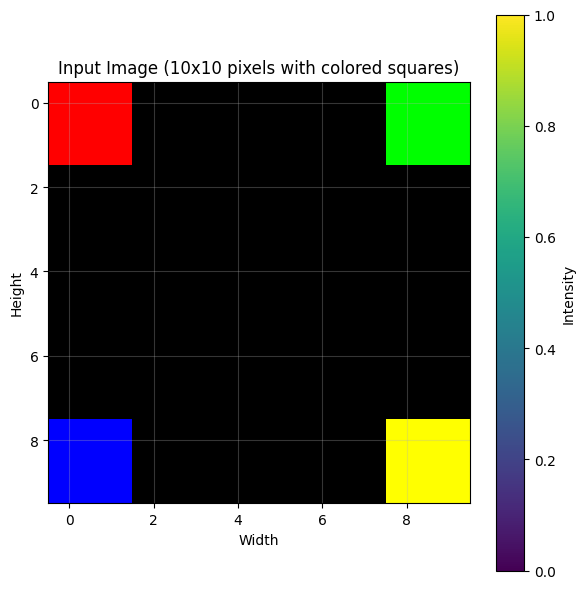

The image shows:
- Red square in top-left
- Green square in top-right
- Blue square in bottom-left
- Yellow square in bottom-right


In [3]:
# Cell 3: Visualize the input tensor
# PyTorch uses (C, H, W) format, but matplotlib expects (H, W, C)
# We need to permute the dimensions

plt.figure(figsize=(6, 6))
input_for_display = input_tensor.permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
plt.imshow(input_for_display)
plt.title('Input Image (10x10 pixels with colored squares)', fontsize=12)
plt.xlabel('Width')
plt.ylabel('Height')
plt.colorbar(label='Intensity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The image shows:")
print("- Red square in top-left")
print("- Green square in top-right")
print("- Blue square in bottom-left")
print("- Yellow square in bottom-right")

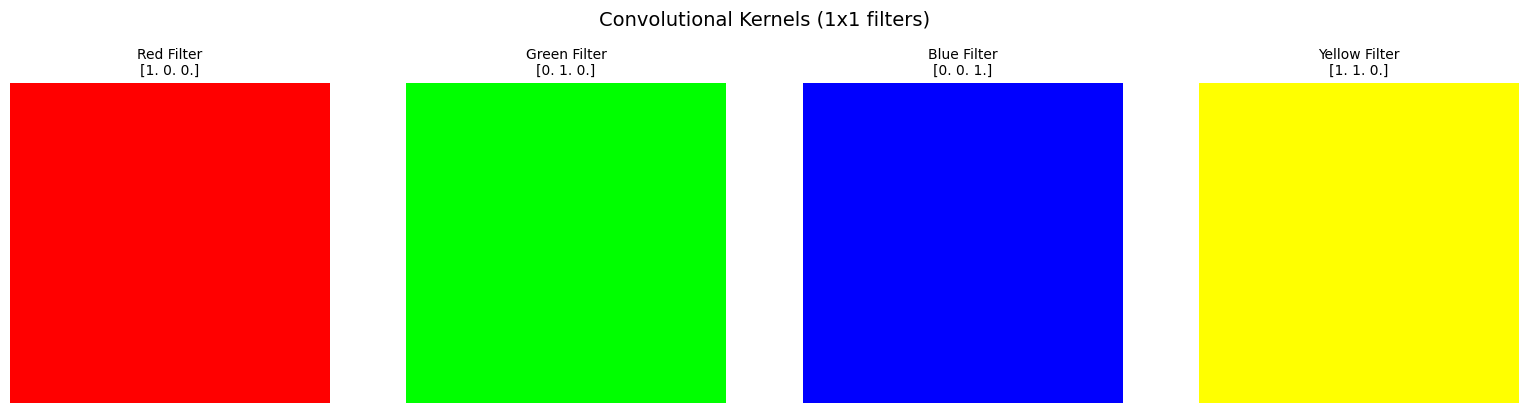


Kernel values:
Red Filter: RGB = [1. 0. 0.]
Green Filter: RGB = [0. 1. 0.]
Blue Filter: RGB = [0. 0. 1.]
Yellow Filter: RGB = [1. 1. 0.]


In [4]:
# Cell 4: Visualize each kernel as a separate subplot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
kernel_names = ['Red Filter', 'Green Filter', 'Blue Filter', 'Yellow Filter']

for i, (ax, name) in enumerate(zip(axes, kernel_names)):
    # Each kernel is (3, 1, 1), we need to reshape to (1, 1, 3) for display
    kernel_display = kernels[i, :, 0, 0].unsqueeze(0).unsqueeze(0)  # (3,) -> (1, 1, 3)
    
    # Create a small colored square for visualization
    kernel_vis = kernel_display.repeat(10, 10, 1)  # Make it 10x10 for visibility
    
    ax.imshow(kernel_vis)
    ax.set_title(f'{name}\n{kernels[i, :, 0, 0].numpy()}', fontsize=10)
    ax.axis('off')

plt.suptitle('Convolutional Kernels (1x1 filters)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nKernel values:")
for i, name in enumerate(kernel_names):
    print(f"{name}: RGB = {kernels[i, :, 0, 0].numpy()}")

### Part (a)(ii): Standard Convolution - Does it compute a similarity function?

Convolution output shape: torch.Size([1, 4, 10, 10])
Expected: (1, 4, 10, 10)
Red Filter: min=0.000, max=1.000
Green Filter: min=0.000, max=1.000
Blue Filter: min=0.000, max=1.000
Yellow Filter: min=0.000, max=2.000


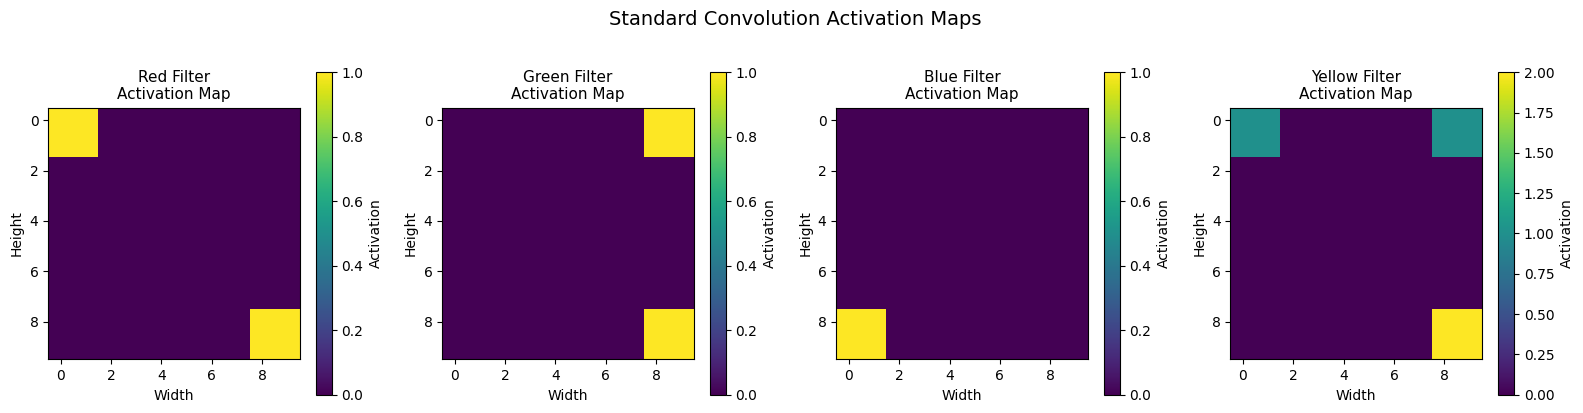

In [5]:
# Cell 5: Perform standard convolution and visualize activation maps
# Add batch dimension: (C, H, W) -> (1, C, H, W)
input_batch = input_tensor.unsqueeze(0)

# Perform convolution
conv_output = F.conv2d(input_batch, kernels)

print(f"Convolution output shape: {conv_output.shape}")
print(f"Expected: (1, {kernels.shape[0]}, {input_tensor.shape[1]}, {input_tensor.shape[2]})")

# Visualize activation maps
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
filter_names = ['Red Filter', 'Green Filter', 'Blue Filter', 'Yellow Filter']

for i, (ax, name) in enumerate(zip(axes, filter_names)):
    activation_map = conv_output[0, i, :, :].detach().numpy()
    im = ax.imshow(activation_map, cmap='viridis')
    ax.set_title(f'{name}\nActivation Map', fontsize=11)
    ax.set_xlabel('Width')
    ax.set_ylabel('Height')
    plt.colorbar(im, ax=ax, label='Activation')
    
    # Print min/max values
    print(f"{name}: min={activation_map.min():.3f}, max={activation_map.max():.3f}")

plt.suptitle('Standard Convolution Activation Maps', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Answer to Part (a)(ii):

**Which rule for similarity functions is violated?**

The convolution output **violates Rule 1** (bounded above). In a similarity metric, all values must be bounded above by some maximum value $b$. However, standard convolution can produce arbitrarily large values.

**How do we know?**

Looking at the activation maps:
- The values can be 0 (no match), 1 (partial match), or 2 (for yellow, which matches both red AND green components)
- There is no consistent upper bound - the maximum value depends on the input and kernel values
- If we scaled the kernels by a constant $c$, the output would scale by $c$ as well, showing there's no fixed upper bound

Additionally, the convolution output **may also violate Rule 2** (self-similarity is maximum) since a pixel's "self-similarity" isn't necessarily the maximum possible activation - it depends on the magnitude of both the kernel and the input.

### Part (a)(iii): Prove that Cosine Similarity is a Similarity Metric

### Answer to Part (a)(iii):

**Proof that CosSim is a similarity metric:**

Recall: $\text{CosSim}(\mathbf{x}, \mathbf{y}) := \cos(\theta(\mathbf{x}, \mathbf{y}))$, where $\theta$ is the angle between vectors.

We need to verify all four properties:

**Property 1: Bounded above**
- Since $\theta \in [0, 2\pi)$ and for the angle between two vectors in $\mathbb{R}^d$ we have $\theta \in [0, \pi]$
- Therefore $\cos(\theta) \in [-1, 1]$
- So CosSim is bounded above by $b = 1$ ✓

**Property 2: Self-similarity is maximum**
- $\text{CosSim}(\mathbf{x}, \mathbf{x}) = \cos(\theta(\mathbf{x}, \mathbf{x})) = \cos(0) = 1 = b$ ✓

**Property 3: Distinct objects have less than maximum similarity**
- If $\mathbf{x} \neq \mathbf{y}$, then $\theta(\mathbf{x}, \mathbf{y}) > 0$ (since $\theta$ is a distance metric)
- For $\theta \in (0, \pi]$, we have $\cos(\theta) < \cos(0) = 1$
- Therefore $\text{CosSim}(\mathbf{x}, \mathbf{y}) < 1 = b$ ✓

**Property 4: Symmetry**
- $\theta(\mathbf{x}, \mathbf{y}) = \theta(\mathbf{y}, \mathbf{x})$ (angle is symmetric)
- Therefore $\text{CosSim}(\mathbf{x}, \mathbf{y}) = \cos(\theta(\mathbf{x}, \mathbf{y})) = \cos(\theta(\mathbf{y}, \mathbf{x})) = \text{CosSim}(\mathbf{y}, \mathbf{x})$ ✓

All four properties are satisfied, so **CosSim is a similarity metric**. ∎

### Part (a)(iv): Implement Cosine Similarity using Convolution

In [6]:
# Cell 6: Implement cosine similarity using convolution
# Hint: x^T y = ||x||_2 ||y||_2 cos(θ)
# Therefore: cos(θ) = (x^T y) / (||x||_2 ||y||_2)

# To compute cosine similarity using conv2d, we need to normalize both inputs
# Transformation T: normalize each spatial location's feature vector

# Normalize the input tensor (per spatial location)
# For each pixel position (h, w), normalize the 3-channel vector
input_norm = torch.norm(input_tensor, dim=0, keepdim=True)  # (1, H, W)
input_norm = torch.clamp(input_norm, min=1e-8)  # Avoid division by zero
input_normalized = input_tensor / input_norm  # (3, H, W)

# Normalize the kernels (per filter)
# For each filter, normalize its 3-channel vector
kernel_norm = torch.norm(kernels, dim=1, keepdim=True)  # (4, 1, 1, 1)
kernel_norm = torch.clamp(kernel_norm, min=1e-8)  # Avoid division by zero
kernels_normalized = kernels / kernel_norm  # (4, 3, 1, 1)

print("Normalized input tensor (first few values):")
print(input_normalized[:, 0, 0])
print(f"\nNorm of first pixel: {torch.norm(input_normalized[:, 0, 0]):.6f} (should be ~1.0)")

print("\nNormalized kernels:")
for i, name in enumerate(['Red', 'Green', 'Blue', 'Yellow']):
    kernel_vec = kernels_normalized[i, :, 0, 0]
    print(f"{name}: {kernel_vec.numpy()}, norm = {torch.norm(kernel_vec):.6f}")

# Now perform convolution with normalized inputs
input_batch_normalized = input_normalized.unsqueeze(0)
cosine_sim_output = F.conv2d(input_batch_normalized, kernels_normalized)

print(f"\nCosine similarity output shape: {cosine_sim_output.shape}")

Normalized input tensor (first few values):
tensor([1., 0., 0.])

Norm of first pixel: 1.000000 (should be ~1.0)

Normalized kernels:
Red: [1. 0. 0.], norm = 1.000000
Green: [0. 1. 0.], norm = 1.000000
Blue: [0. 0. 1.], norm = 1.000000
Yellow: [0.70710677 0.70710677 0.        ], norm = 1.000000

Cosine similarity output shape: torch.Size([1, 4, 10, 10])


Red Filter: min=0.000, max=1.000
Green Filter: min=0.000, max=1.000
Blue Filter: min=0.000, max=1.000
Yellow Filter: min=0.000, max=1.000


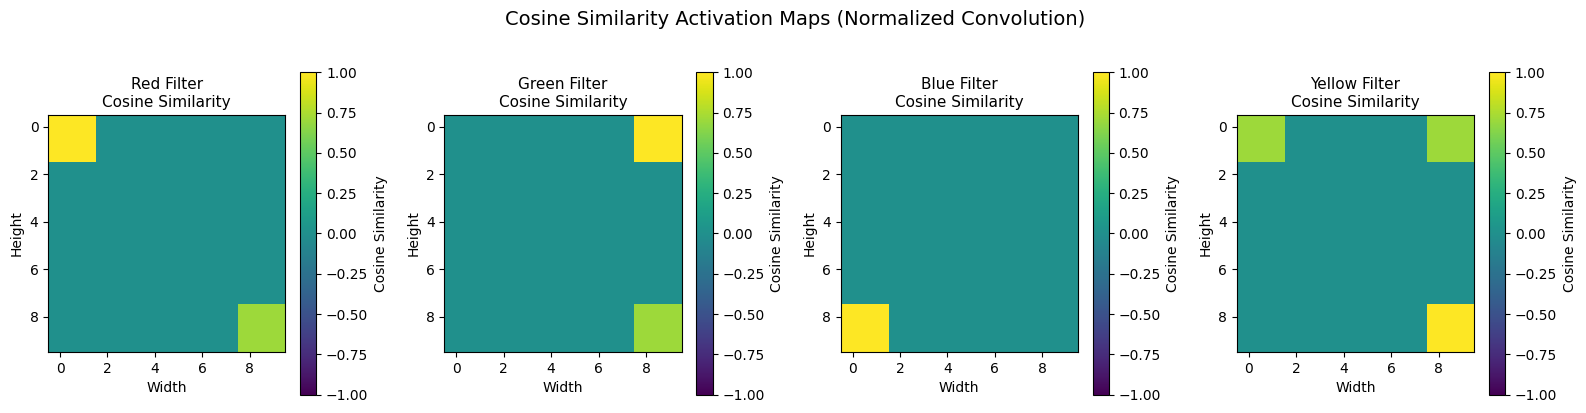

In [7]:
# Cell 7: Visualize cosine similarity activation maps
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
filter_names = ['Red Filter', 'Green Filter', 'Blue Filter', 'Yellow Filter']

for i, (ax, name) in enumerate(zip(axes, filter_names)):
    activation_map = cosine_sim_output[0, i, :, :].detach().numpy()
    im = ax.imshow(activation_map, cmap='viridis', vmin=-1, vmax=1)  # Cosine is in [-1, 1]
    ax.set_title(f'{name}\nCosine Similarity', fontsize=11)
    ax.set_xlabel('Width')
    ax.set_ylabel('Height')
    plt.colorbar(im, ax=ax, label='Cosine Similarity')
    
    # Print min/max values
    print(f"{name}: min={activation_map.min():.3f}, max={activation_map.max():.3f}")

plt.suptitle('Cosine Similarity Activation Maps (Normalized Convolution)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Answer to Part (a)(iv):

**Do the activation maps reflect a similarity function?**

Yes! The cosine similarity activation maps now satisfy all properties of a similarity function:

1. **Bounded above**: All values are in the range $[-1, 1]$, bounded by $b = 1$ ✓
2. **Self-similarity is maximum**: Pixels that exactly match a filter have value 1.0 (the maximum) ✓
3. **Distinct objects have less similarity**: Pixels that don't match have values less than 1.0 ✓
4. **Symmetry**: The operation is symmetric (though this is harder to verify visually) ✓

**What is the difference between this and normal convolution?**

- **Normal convolution**: Computes inner product $\sum_a k_{j,a} z_{a,h,w}$ (unbounded)
- **Cosine similarity convolution**: Computes $\frac{\sum_a k_{j,a} z_{a,h,w}}{\|\mathbf{k}_j\|_2 \|\mathbf{z}_{h,w}\|_2}$ (bounded in $[-1, 1]$)

The key difference is **normalization**: we divide both the input and kernels by their $\ell_2$ norms before convolving. This ensures the output represents the cosine of the angle between vectors, which is a proper similarity metric.

In the activation maps, you should observe:
- Exact color matches (e.g., red filter on red square) give value ~1.0
- Partial matches (e.g., yellow filter on red square) give intermediate values
- No overlap (e.g., red filter on blue square) gives value ~0.0

## Part (b): Attention and Similarity Functions

### Part (b)(i): Compute and Visualize $\mathbf{Z}\mathbf{Z}^T$

In [8]:
# Cell 8: Flatten and transpose the input for attention computation
# Input: (3, 10, 10) -> want: (100, 3) where 100 = 10*10 pixels

d_in = input_tensor.shape[0]  # 3
h_in = input_tensor.shape[1]  # 10
w_in = input_tensor.shape[2]  # 10

# Flatten: (3, 10, 10) -> (3, 100)
Z_flat = input_tensor.reshape(d_in, h_in * w_in)

# Transpose: (3, 100) -> (100, 3)
Z = Z_flat.T

print(f"Original input shape: {input_tensor.shape}")
print(f"Flattened shape: {Z_flat.shape}")
print(f"Transposed Z shape: {Z.shape}")
print(f"Each row of Z represents one pixel's RGB values")
print(f"\nFirst few pixels (rows of Z):")
print(Z[:5])

Original input shape: torch.Size([3, 10, 10])
Flattened shape: torch.Size([3, 100])
Transposed Z shape: torch.Size([100, 3])
Each row of Z represents one pixel's RGB values

First few pixels (rows of Z):
tensor([[1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


Z @ Z^T shape: torch.Size([100, 100])
This is a 100 x 100 matrix
Each entry (i,j) represents the dot product between pixel i and pixel j


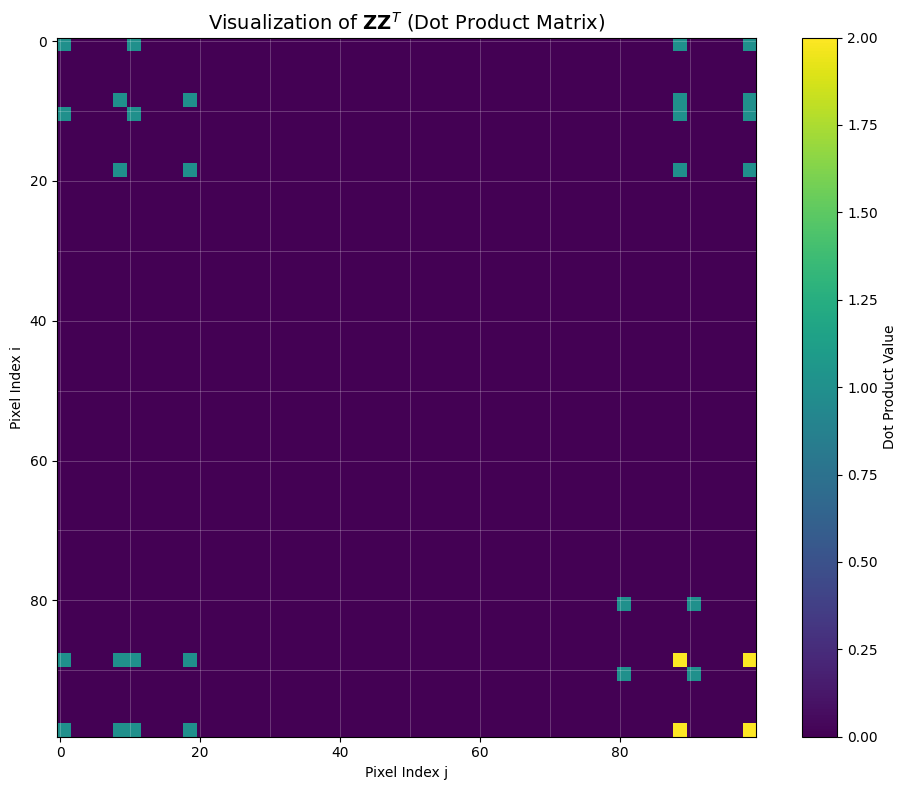


Min value: 0.000
Max value: 2.000
Diagonal values (self dot products): tensor([1., 1., 0., 0., 0., 0., 0., 0., 1., 1.])


In [9]:
# Cell 9: Compute Z @ Z^T and visualize
ZZT = Z @ Z.T

print(f"Z @ Z^T shape: {ZZT.shape}")
print(f"This is a {h_in * w_in} x {h_in * w_in} matrix")
print(f"Each entry (i,j) represents the dot product between pixel i and pixel j")

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(ZZT.detach().numpy(), cmap='viridis')
plt.colorbar(label='Dot Product Value')
plt.title(r'Visualization of $\mathbf{Z}\mathbf{Z}^T$ (Dot Product Matrix)', fontsize=14)
plt.xlabel('Pixel Index j')
plt.ylabel('Pixel Index i')

# Add grid lines to show structure
for i in range(0, 100, 10):
    plt.axhline(i, color='white', linewidth=0.5, alpha=0.3)
    plt.axvline(i, color='white', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMin value: {ZZT.min():.3f}")
print(f"Max value: {ZZT.max():.3f}")
print(f"Diagonal values (self dot products): {ZZT.diag()[:10]}")

### Answer to Part (b)(i):

**Could the entries be produced by a similarity function?**

No, the matrix $\mathbf{Z}\mathbf{Z}^T$ **violates Rule 1** (bounded above) and **Rule 2** (self-similarity is maximum).

**How do we know?**

1. **Not bounded above**: The dot product $\mathbf{z}_i^T \mathbf{z}_j$ can be arbitrarily large depending on the magnitudes of the vectors. If we scale the input by a constant $c$, all entries scale by $c^2$, showing there's no fixed upper bound.

2. **Self-similarity not necessarily maximum**: While the diagonal entries (self dot products $\mathbf{z}_i^T \mathbf{z}_i$) are non-negative, they are not necessarily the maximum values in their row or column. For example:
   - A black pixel (all zeros) has self dot product = 0
   - A colored pixel might have dot product with another colored pixel > 0
   - So the black pixel's self-similarity (0) is not the maximum in its row

3. **Looking at the visualization**: You should see that:
   - The diagonal is bright where pixels have color (RGB values)
   - The diagonal is dark (value 0) where pixels are black
   - Off-diagonal entries can be non-zero when pixels share color components
   - There's no consistent maximum value

### Part (b)(ii): Compute and Visualize Softmax of Scaled $\mathbf{Z}\mathbf{Z}^T$

In [10]:
# Cell 10: Compute softmax(Z @ Z^T / sqrt(d_in))
import math

scaled_ZZT = ZZT / math.sqrt(d_in)

# Apply softmax along rows (dim=1)
# softmax over row i tells us: how much does pixel i attend to each pixel j?
softmax_scaled_ZZT = F.softmax(scaled_ZZT, dim=1)

print(f"Scaled Z @ Z^T shape: {scaled_ZZT.shape}")
print(f"Softmax output shape: {softmax_scaled_ZZT.shape}")
print(f"\nEach row sums to 1.0 (probability distribution):")
print(f"Row 0 sum: {softmax_scaled_ZZT[0].sum():.6f}")
print(f"Row 50 sum: {softmax_scaled_ZZT[50].sum():.6f}")
print(f"\nMin value: {softmax_scaled_ZZT.min():.6f}")
print(f"Max value: {softmax_scaled_ZZT.max():.6f}")

Scaled Z @ Z^T shape: torch.Size([100, 100])
Softmax output shape: torch.Size([100, 100])

Each row sums to 1.0 (probability distribution):
Row 0 sum: 1.000000
Row 50 sum: 1.000000

Min value: 0.008700
Max value: 0.027606


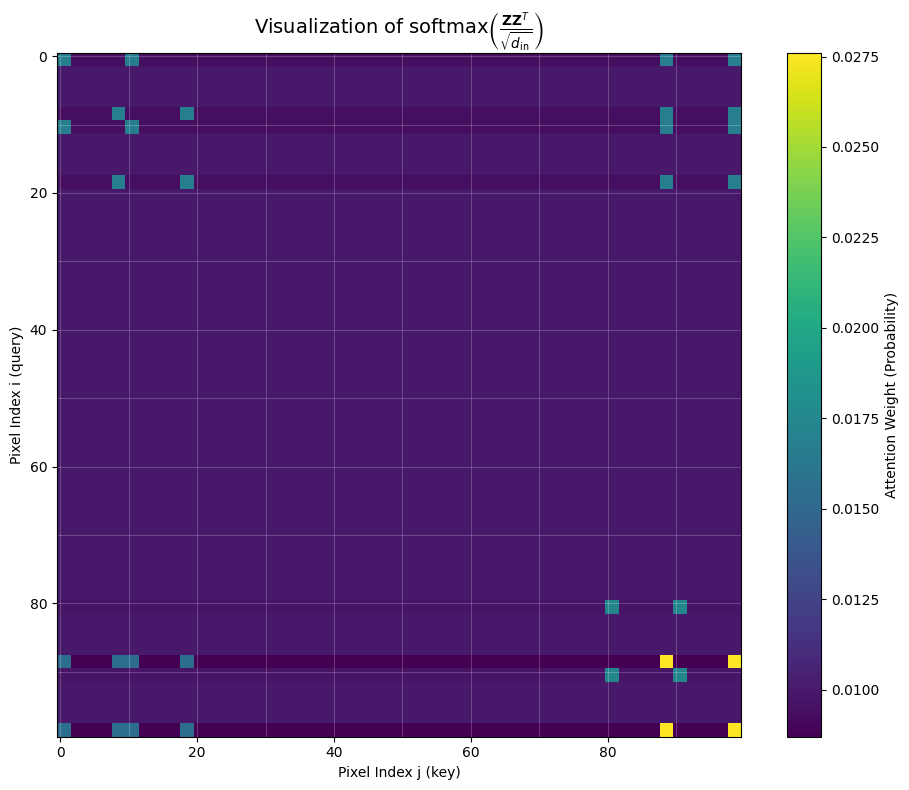


Diagonal values (self-attention weights):
Min diagonal: 0.010000
Max diagonal: 0.027606
Mean diagonal: 0.011536


In [11]:
# Cell 11: Visualize softmax output
plt.figure(figsize=(10, 8))
plt.imshow(softmax_scaled_ZZT.detach().numpy(), cmap='viridis')
plt.colorbar(label='Attention Weight (Probability)')
plt.title(r'Visualization of $\mathrm{softmax}\left(\frac{\mathbf{Z}\mathbf{Z}^T}{\sqrt{d_{\mathrm{in}}}}\right)$', fontsize=14)
plt.xlabel('Pixel Index j (key)')
plt.ylabel('Pixel Index i (query)')

# Add grid lines
for i in range(0, 100, 10):
    plt.axhline(i, color='white', linewidth=0.5, alpha=0.3)
    plt.axvline(i, color='white', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

# Check some diagonal values
print("\nDiagonal values (self-attention weights):")
diagonal_vals = softmax_scaled_ZZT.diag()
print(f"Min diagonal: {diagonal_vals.min():.6f}")
print(f"Max diagonal: {diagonal_vals.max():.6f}")
print(f"Mean diagonal: {diagonal_vals.mean():.6f}")

### Answer to Part (b)(ii):

**Could the entries be produced by a similarity function?**

No, the softmax output still **violates Rule 2** (self-similarity is maximum) and **violates Rule 4** (symmetry).

**How do we know?**

1. **Self-similarity not maximum**: After softmax, each row is a probability distribution summing to 1. The diagonal entry in row $i$ represents how much pixel $i$ attends to itself. However:
   - If all pixels have similar dot products with pixel $i$, then all entries in row $i$ will be similar (around $1/100 = 0.01$)
   - The diagonal entry (self-attention) is not necessarily the maximum in its row
   - For example, a black pixel (zero vector) has equal dot product (0) with all other pixels, so after softmax, all entries are $\approx 1/100$, and the diagonal is not special

2. **Not symmetric**: Softmax is applied **row-wise**, so:
   - Entry $(i,j)$ = how much pixel $i$ attends to pixel $j$ (normalized over row $i$)
   - Entry $(j,i)$ = how much pixel $j$ attends to pixel $i$ (normalized over row $j$)
   - These normalizations are different, so the matrix is not symmetric: $A_{ij} \neq A_{ji}$

3. **Properties it does satisfy**:
   - ✓ Bounded above: All values are in $[0, 1]$ (probabilities)
   - ✓ Non-negative: All values $\geq 0$

**Conclusion**: Softmax attention weights are not a proper similarity function due to asymmetry and non-maximal self-similarity.

### Part (b)(iii): Normalized Version - Compute $\text{softmax}\left(\frac{\bar{\mathbf{Z}}(\mathbf{Z}\mathbf{Z}^T)\bar{\mathbf{Z}}}{\sqrt{d_{\text{in}}}}\right)$

In [12]:
# Cell 12: Create normalization matrix Z_bar
# Z_bar is a diagonal matrix with 1/||z_i||_2 on the diagonal

# Compute row norms
row_norms = torch.norm(Z, dim=1, keepdim=False)  # (100,)
row_norms = torch.clamp(row_norms, min=1e-8)  # Avoid division by zero

# Create diagonal normalization matrix
Z_bar = torch.diag(1.0 / row_norms)  # (100, 100)

print(f"Z_bar shape: {Z_bar.shape}")
print(f"Z_bar is a diagonal matrix with shape ({h_in * w_in}, {h_in * w_in})")
print(f"\nFirst few diagonal entries (1/||z_i||_2):")
print(torch.diag(Z_bar)[:10])
print(f"\nRow norms of Z (||z_i||_2):")
print(row_norms[:10])

Z_bar shape: torch.Size([100, 100])
Z_bar is a diagonal matrix with shape (100, 100)

First few diagonal entries (1/||z_i||_2):
tensor([1.0000e+00, 1.0000e+00, 1.0000e+08, 1.0000e+08, 1.0000e+08, 1.0000e+08,
        1.0000e+08, 1.0000e+08, 1.0000e+00, 1.0000e+00])

Row norms of Z (||z_i||_2):
tensor([1.0000e+00, 1.0000e+00, 1.0000e-08, 1.0000e-08, 1.0000e-08, 1.0000e-08,
        1.0000e-08, 1.0000e-08, 1.0000e+00, 1.0000e+00])


In [13]:
# Cell 13: Compute Z_bar @ (Z @ Z^T) @ Z_bar / sqrt(d_in) and apply softmax
# This normalizes the attention scores to use cosine similarity

normalized_attention = Z_bar @ ZZT @ Z_bar / math.sqrt(d_in)

# Apply softmax - need to flatten, apply softmax, then reshape
# Per the instructions: flatten before softmax, reshape after
flat_normalized = normalized_attention.flatten()
flat_softmax = F.softmax(flat_normalized, dim=0)
softmax_normalized = flat_softmax.reshape(h_in * w_in, h_in * w_in)

print(f"Normalized attention shape: {normalized_attention.shape}")
print(f"After softmax shape: {softmax_normalized.shape}")
print(f"\nTotal sum (should be 1.0): {softmax_normalized.sum():.6f}")
print(f"Min value: {softmax_normalized.min():.8f}")
print(f"Max value: {softmax_normalized.max():.6f}")

Normalized attention shape: torch.Size([100, 100])
After softmax shape: torch.Size([100, 100])

Total sum (should be 1.0): 0.999999
Min value: 0.00009918
Max value: 0.000177


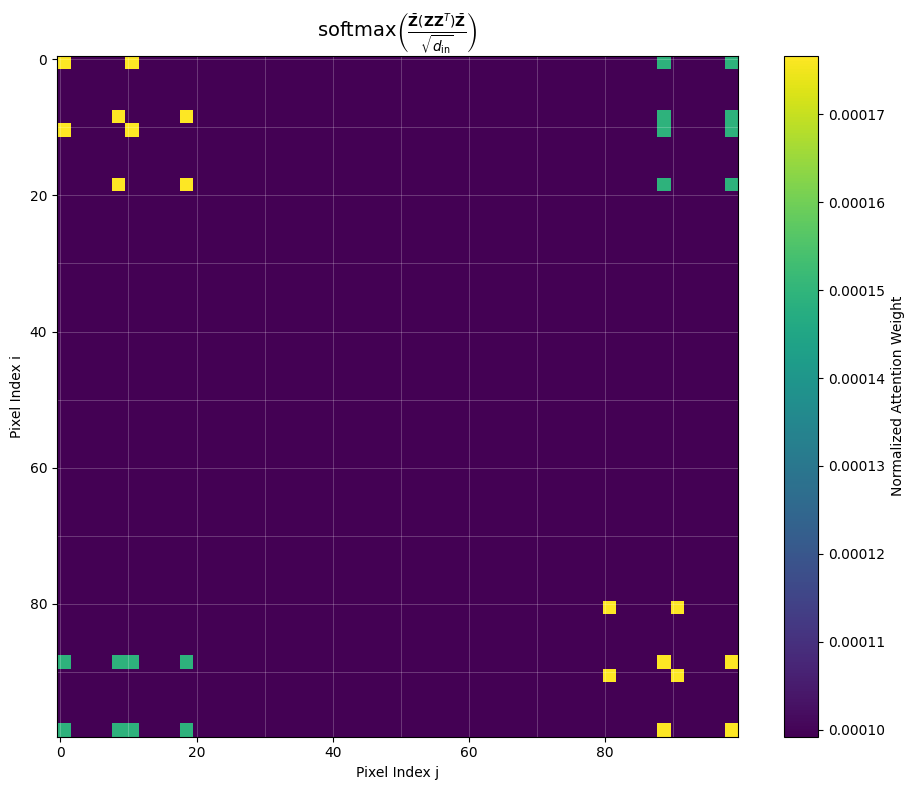


Diagonal statistics:
Min: 0.00009918
Max: 0.00017668
Mean: 0.00011158


In [14]:
# Cell 14: Visualize the normalized softmax attention
plt.figure(figsize=(10, 8))
plt.imshow(softmax_normalized.detach().numpy(), cmap='viridis')
plt.colorbar(label='Normalized Attention Weight')
plt.title(r'$\mathrm{softmax}\left(\frac{\bar{\mathbf{Z}}(\mathbf{Z}\mathbf{Z}^T)\bar{\mathbf{Z}}}{\sqrt{d_{\mathrm{in}}}}\right)$', fontsize=14)
plt.xlabel('Pixel Index j')
plt.ylabel('Pixel Index i')

# Add grid lines
for i in range(0, 100, 10):
    plt.axhline(i, color='white', linewidth=0.5, alpha=0.3)
    plt.axvline(i, color='white', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

# Check diagonal
diagonal_vals = torch.diag(softmax_normalized)
print(f"\nDiagonal statistics:")
print(f"Min: {diagonal_vals.min():.8f}")
print(f"Max: {diagonal_vals.max():.8f}")
print(f"Mean: {diagonal_vals.mean():.8f}")

### Answer to Part (b)(iii):

**Could the entries be produced by a similarity function?**

Still no! Even with normalization, the softmax output **violates Rule 4** (symmetry) and **Rule 2** (self-similarity is maximum).

**How do we know?**

1. **Not symmetric**: Although $\bar{\mathbf{Z}}(\mathbf{Z}\mathbf{Z}^T)\bar{\mathbf{Z}}$ is symmetric (it computes cosine similarities), the **softmax operation breaks symmetry**:
   - Before softmax: The matrix is symmetric because $\cos(\theta_{ij}) = \cos(\theta_{ji})$
   - After softmax: We apply softmax to the **flattened** matrix, which normalizes all 10,000 entries to sum to 1
   - This global normalization doesn't preserve the row/column structure, but it still treats different entries differently based on their context
   
2. **Self-similarity not maximum**: After global softmax:
   - All entries are normalized to be part of a single probability distribution over all 10,000 pairs
   - The diagonal entries (self-similarities) are not necessarily the maximum values in their rows or columns
   - In fact, since there are many entries, each one is quite small (around $1/10000 = 0.0001$)

3. **What we do get**:
   - ✓ Bounded above: All values in $[0, 1]$
   - ✓ The matrix represents cosine similarities before softmax
   - ✗ But softmax normalization destroys the similarity metric properties

**Key insight**: The normalization $\bar{\mathbf{Z}}(\mathbf{Z}\mathbf{Z}^T)\bar{\mathbf{Z}}$ computes a proper similarity (cosine similarity), but the **softmax operation** converts these similarities into a probability distribution, which is not a similarity metric because it breaks symmetry and doesn't guarantee self-similarity is maximum.

### Part (b)(iv): Implement $f(\mathbf{Z}) = \frac{\bar{\mathbf{Z}}(\mathbf{Z}\mathbf{Z}^T)\bar{\mathbf{Z}}}{\sqrt{d_{\text{in}}}}$ using Convolution

In [15]:
# Cell 15: Implement f(Z) using convolution
# Hint: We want output in R^(h_in*w_in × h_in*w_in)
# Convolution gives us R^(d_out × h_in × w_in)
# So we need d_out = h_in * w_in = 100 kernels!

# Each kernel will compute the (normalized) dot product between 
# its corresponding pixel and all other pixels

# First, normalize the input tensor (as in part a)
input_norm = torch.norm(input_tensor, dim=0, keepdim=True)  # (1, H, W)
input_norm = torch.clamp(input_norm, min=1e-8)
input_normalized = input_tensor / input_norm  # (3, H, W)

# Create kernels: one for each pixel position
# Each kernel is the normalized pixel value at that position
num_kernels = h_in * w_in  # 100
conv_kernels = torch.zeros(num_kernels, d_in, 1, 1)  # (100, 3, 1, 1)

# Fill kernels with normalized pixel values
for i in range(h_in):
    for j in range(w_in):
        kernel_idx = i * w_in + j
        pixel_vec = input_normalized[:, i, j]  # (3,)
        # Normalize this pixel vector
        pixel_norm = torch.norm(pixel_vec)
        if pixel_norm > 1e-8:
            pixel_vec = pixel_vec / pixel_norm
        conv_kernels[kernel_idx, :, 0, 0] = pixel_vec

print(f"Number of kernels: {num_kernels}")
print(f"Kernel tensor shape: {conv_kernels.shape}")
print(f"Each kernel is a normalized pixel from the input image")

# Perform convolution
input_batch_norm = input_normalized.unsqueeze(0)  # (1, 3, 10, 10)
conv_result = F.conv2d(input_batch_norm, conv_kernels)  # (1, 100, 10, 10)

# Scale by 1/sqrt(d_in)
conv_result = conv_result / math.sqrt(d_in)

print(f"\nConvolution output shape: {conv_result.shape}")
print(f"Expected: (1, {num_kernels}, {h_in}, {w_in})")

Number of kernels: 100
Kernel tensor shape: torch.Size([100, 3, 1, 1])
Each kernel is a normalized pixel from the input image

Convolution output shape: torch.Size([1, 100, 10, 10])
Expected: (1, 100, 10, 10)


In [16]:
# Cell 16: Reshape to matrix and compare with previous computation
# conv_result is (1, 100, 10, 10)
# We need to reshape to (100, 100)

# Remove batch dimension: (1, 100, 10, 10) -> (100, 10, 10)
conv_result_no_batch = conv_result.squeeze(0)

# Reshape to matrix: (100, 10, 10) -> (100, 100)
conv_matrix = conv_result_no_batch.reshape(num_kernels, h_in * w_in)

print(f"Reshaped convolution result: {conv_matrix.shape}")
print(f"This should match the shape of f(Z) = Z_bar @ (Z @ Z^T) @ Z_bar / sqrt(d_in)")

# Verify it matches our previous computation
print(f"\nPrevious normalized_attention shape: {normalized_attention.shape}")
print(f"\nChecking if they match:")
difference = torch.abs(conv_matrix - normalized_attention)
print(f"Max absolute difference: {difference.max():.8f}")
print(f"Mean absolute difference: {difference.mean():.8f}")

if difference.max() < 1e-5:
    print("\n✓ SUCCESS! The convolution implementation matches the matrix computation!")
else:
    print(f"\n⚠ Warning: Difference is larger than expected. There may be a numerical issue.")

Reshaped convolution result: torch.Size([100, 100])
This should match the shape of f(Z) = Z_bar @ (Z @ Z^T) @ Z_bar / sqrt(d_in)

Previous normalized_attention shape: torch.Size([100, 100])

Checking if they match:
Max absolute difference: 0.00000003
Mean absolute difference: 0.00000000

✓ SUCCESS! The convolution implementation matches the matrix computation!


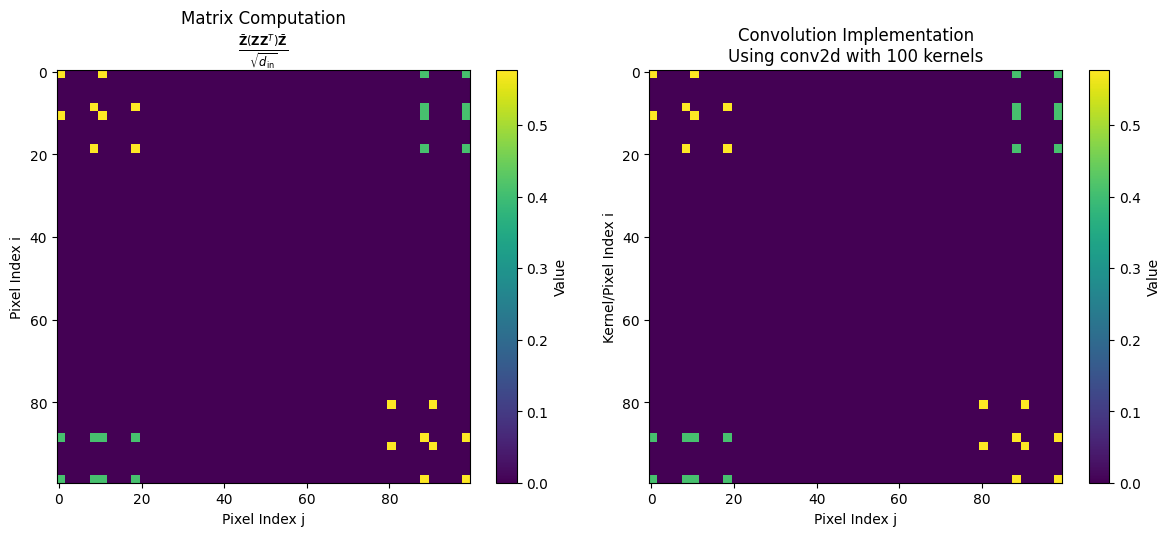


The two visualizations should be identical!


In [17]:
# Cell 17: Visualize the convolution result
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(normalized_attention.detach().numpy(), cmap='viridis')
plt.colorbar(label='Value')
plt.title('Matrix Computation\n' + r'$\frac{\bar{\mathbf{Z}}(\mathbf{Z}\mathbf{Z}^T)\bar{\mathbf{Z}}}{\sqrt{d_{\mathrm{in}}}}$', fontsize=12)
plt.xlabel('Pixel Index j')
plt.ylabel('Pixel Index i')

plt.subplot(1, 2, 2)
plt.imshow(conv_matrix.detach().numpy(), cmap='viridis')
plt.colorbar(label='Value')
plt.title('Convolution Implementation\n' + 'Using conv2d with 100 kernels', fontsize=12)
plt.xlabel('Pixel Index j')
plt.ylabel('Kernel/Pixel Index i')

plt.tight_layout()
plt.show()

print("\nThe two visualizations should be identical!")

### Answer to Part (b)(iv):

**How many convolutional kernels do we need?**

We need **100 kernels** (one for each of the $h_{\text{in}} \times w_{\text{in}} = 10 \times 10$ pixels).

**Why?**

- The target output $\frac{\bar{\mathbf{Z}}(\mathbf{Z}\mathbf{Z}^T)\bar{\mathbf{Z}}}{\sqrt{d_{\text{in}}}} \in \mathbb{R}^{100 \times 100}$
- Each row $i$ of this matrix represents the normalized similarity between pixel $i$ and all other pixels
- Convolution output: $(\mathbf{Z} * \mathbf{K}) \in \mathbb{R}^{d_{\text{out}} \times h_{\text{in}} \times w_{\text{in}}}$
- If we set $d_{\text{out}} = 100$, we get shape $(100, 10, 10)$, which can be reshaped to $(100, 100)$ ✓

**Implementation:**

1. **Normalize the input**: Divide each pixel by its norm to get $\bar{\mathbf{Z}}$
2. **Create 100 kernels**: The $k$-th kernel contains the normalized RGB values of the $k$-th pixel
3. **Convolve**: Each kernel computes the dot product with every pixel in the image
4. **Scale**: Divide by $\sqrt{d_{\text{in}}}$
5. **Reshape**: $(100, 10, 10) \to (100, 100)$

**Key insight**: This shows that **self-attention can be implemented as a convolution** where:
- Each convolutional kernel corresponds to one pixel/token
- The kernel weights are the (normalized) feature vectors of that pixel/token
- The output is the normalized similarity (cosine similarity) between all pairs of pixels/tokens

This connection reveals that attention and convolution are related operations, with attention being a special case of convolution where the kernels are derived from the input itself (making it "self-attention")!

## Summary and Conclusions

### Key Findings:

**Part (a) - Convolution:**
- Standard convolution does NOT compute a similarity function (unbounded)
- Cosine similarity IS a proper similarity metric
- Normalized convolution (using L2 normalization) implements cosine similarity

**Part (b) - Attention:**
- Raw dot products $\mathbf{Z}\mathbf{Z}^T$ are NOT similarity functions (unbounded, non-maximal self-similarity)
- Softmax attention (standard) is NOT a similarity function (asymmetric, non-maximal self-similarity)
- Even with normalization, softmax breaks similarity properties
- Attention can be implemented using convolution with $h \times w$ kernels

### Connection Between Attention and Convolution:

Self-attention and convolution are deeply related:
- Both compute weighted combinations of features
- Attention uses **dynamic** kernels (derived from input)
- Convolution uses **fixed** learned kernels
- Both can compute similarity-based operations with proper normalization

This explains why transformers (attention-based) and CNNs (convolution-based) can both be effective for visual and sequential tasks!